# DS14: Dungeness Crab Cohort Biomass, US Pacific Coast, USA

The Dungeness crab (Metacarcinus magister ) supports one of the most valuable commercial fisheries
on the US Pacific Coast, USA. Stock assessment biologists track annual cohort biomass (metric
tons) at the point of recruitment. A cohort is the group of crabs born in the same year; cohort
biomass is the total mass of that group as it enters the harvestable population. Cohort biomass
grows from a small initial value toward an equilibrium set by habitat and food availability. The
cohort biomass at t = 0 is approximately 138 metric tons.
QOI: Cohort biomass Nt (metric tons) in time step t, where t = 0, 1, 2, . . . denotes the year index.
Fit: r (dimensionless) and K (metric tons).

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset without the saved index becoming a normal column
data = pd.read_csv('DS14.csv', index_col=0)
data.head()


,cohort_biomass_mt
year,
0,138.0
1,246.0
2,528.0
3,940.0
4,913.0


In [12]:
# Turning the dataset into a numpy array for cohort biomass since the years are linearly spaced
N = data["cohort_biomass_mt"].to_numpy(dtype=float)

Discrete Logistic Model
$ N[t+1] = N[t] * (1 + r * (1 - N[t]/K)) $

r = 1.0847, K = 6626.57


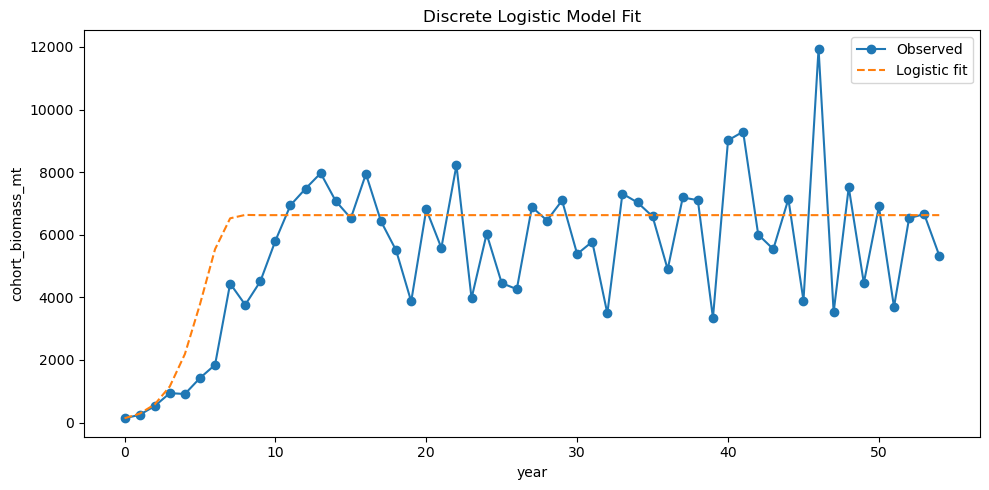

In [13]:
# Estimate r and K from g_t = N[t+1]/N[t] - 1 = r - (r/K)N[t]
slope, r = np.polyfit(N[:-1], N[1:] / N[:-1] - 1, 1)
K = -r / slope

# Simulate discrete logistic model
N_fit = [N[0]]
for i in range(len(N) - 1):
    N_fit.append(N_fit[-1] * (1 + r * (1 - N_fit[-1] / K)))

print(f"r = {r:.4f}, K = {K:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_fit, "--", label="Logistic fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Discrete Logistic Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

Smith-Slatkin Discrete: $N[t]= N[t] * e^r \ 1 + (e^r-1) * N[t] / K$

Smith-Slatkin r = 0.6379, K = 5412.44


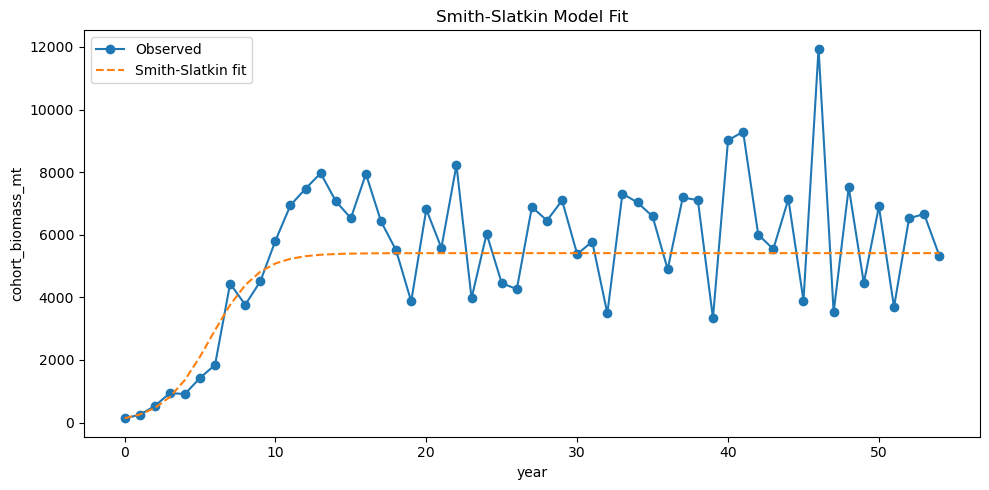

In [14]:

# Linearization: 1/N[t+1] = (1/R)(1/N[t]) + (R-1)/(R K), where R = e^r
a, b = np.polyfit(1 / N[:-1], 1 / N[1:], 1)
R = 1 / a
r_ss = np.log(R)
K_ss = (R - 1) / (R * b)

N_ss = [N[0]]
for i in range(len(N) - 1):
    prev = N_ss[-1]
    N_ss.append((prev * R) / (1 + (R - 1) * prev / K_ss))

print(f"Smith-Slatkin r = {r_ss:.4f}, K = {K_ss:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_ss, "--", label="Smith-Slatkin fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Smith-Slatkin Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

Beverton-Holt lambda = 4.9688, alpha = 0.000769


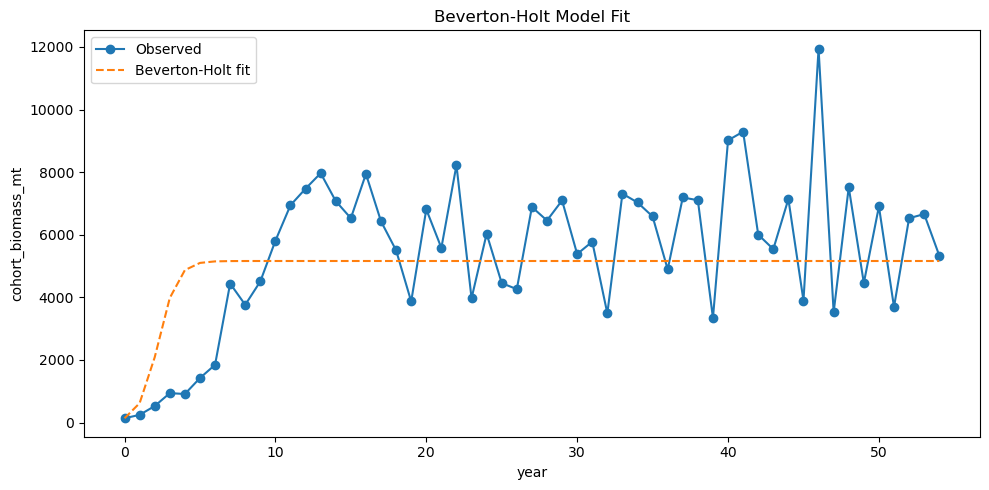

In [15]:
# Beverton-Holt: N[t+1] = (lambda * N[t]) / (1 + alpha * N[t])
N = data["cohort_biomass_mt"].to_numpy(dtype=float)
# N = np.log(N)

# Using np_polyfit to find out the lambda and alpha params

m, c = np.polyfit(N[:-1], N[:-1] / N[1:], 1)
lam = 1 / c
alpha = m * lam

N_bh = [N[0]]
for i in range(len(N) - 1):
    prev = N_bh[-1]
    N_bh.append((lam * prev) / (1 + alpha * prev))

print(f"Beverton-Holt lambda = {lam:.4f}, alpha = {alpha:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_bh, "--", label="Beverton-Holt fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Beverton-Holt Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

Ricker r = 0.8469, K = 5922.71


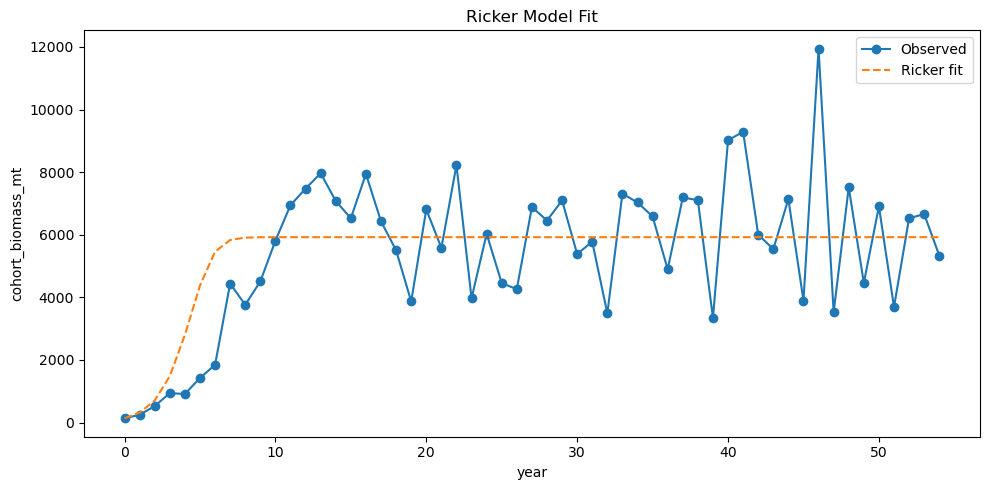

Theta-Ricker (theta=0.7) r = 0.9996, K = 5776.99


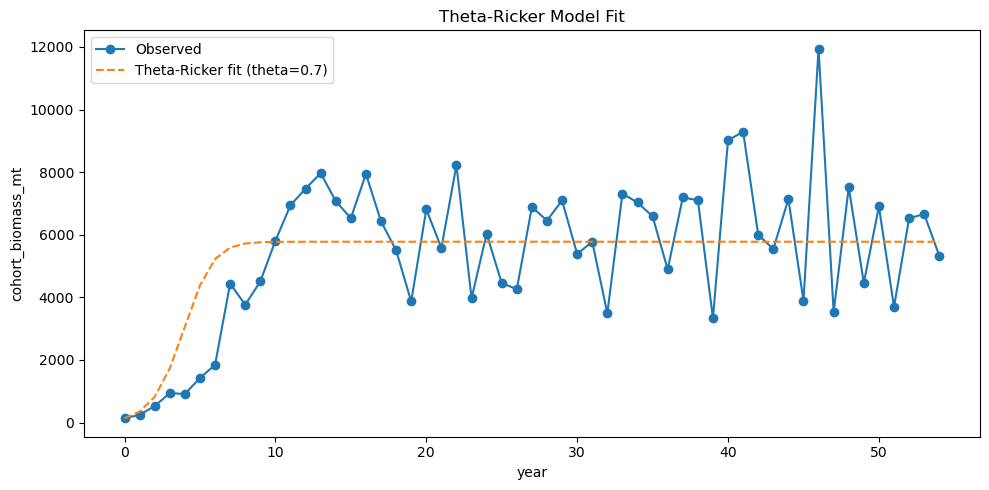

In [16]:
# Ricker and Theta-Ricker fits

# Use only positive transitions for log-ratio linearization
mask = (N[:-1] > 0) & (N[1:] > 0)
N_t = N[:-1][mask]
N_t1 = N[1:][mask]
log_ratio = np.log(N_t1 / N_t)

# 4) Ricker: N[t+1] = N[t] * exp(r * (1 - N[t]/K))
# Linear form: log(N[t+1]/N[t]) = r - (r/K) * N[t]
slope_r, r_ricker = np.polyfit(N_t, log_ratio, 1)
K_ricker = -r_ricker / slope_r

N_ricker = [N[0]]
for i in range(len(N) - 1):
    prev = N_ricker[-1]
    N_ricker.append(prev * np.exp(r_ricker * (1 - prev / K_ricker)))

print(f"Ricker r = {r_ricker:.4f}, K = {K_ricker:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_ricker, "--", label="Ricker fit")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Ricker Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Theta-Ricker with theta fixed at 0.7:
# N[t+1] = N[t] * exp(r * (1 - (N[t]/K)^theta))
# Linear form: log(N[t+1]/N[t]) = r - (r/K^theta) * N[t]^theta
theta = 0.7
X_theta = N_t ** theta
slope_th, r_theta = np.polyfit(X_theta, log_ratio, 1)
K_theta = (-r_theta / slope_th) ** (1 / theta)

N_theta = [N[0]]
for i in range(len(N) - 1):
    prev = N_theta[-1]
    N_theta.append(prev * np.exp(r_theta * (1 - (prev / K_theta) ** theta)))

print(f"Theta-Ricker (theta={theta}) r = {r_theta:.4f}, K = {K_theta:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(data.index, N, "o-", label="Observed")
plt.plot(data.index, N_theta, "--", label=f"Theta-Ricker fit (theta={theta})")
plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Theta-Ricker Model Fit")
plt.legend()
plt.tight_layout()
plt.show()

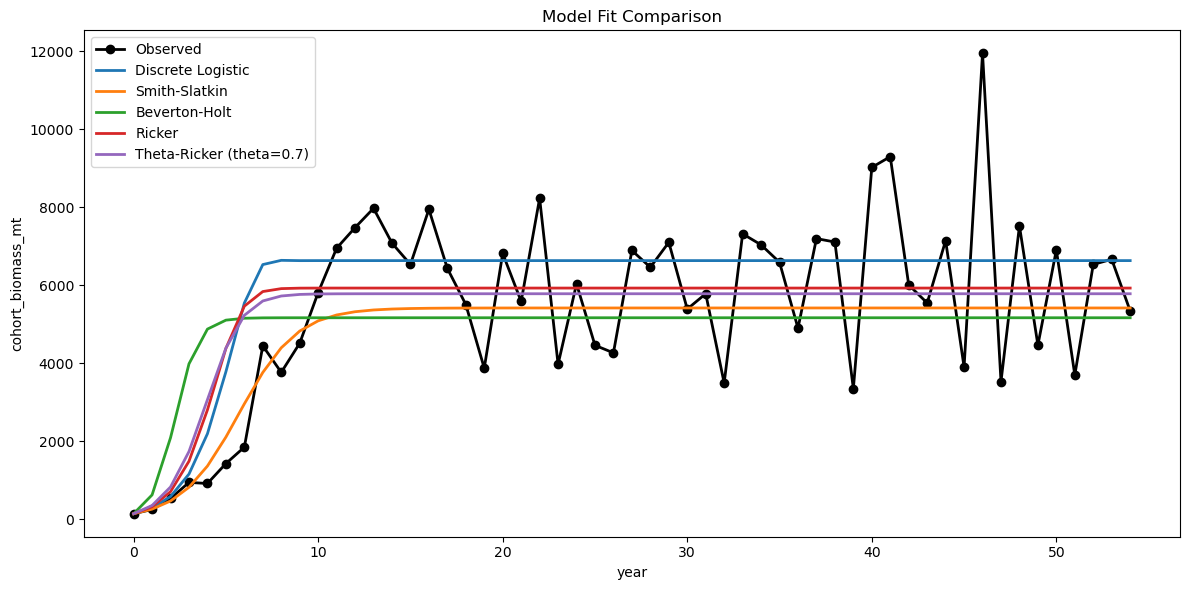

Model ranking (best to worst by RMSE):
                   Model      RMSE       MAE     AICc      BIC
           Smith-Slatkin 1745.9428 1339.1094 825.3863 829.1702
                  Ricker 1762.4972 1385.2849 826.4243 830.2082
Theta-Ricker (theta=0.7) 1778.8227 1407.6238 827.4385 831.2224
       Discrete Logistic 1792.3890 1345.8267 828.2743 832.0582
           Beverton-Holt 2086.1443 1693.1751 844.9688 848.7527

Best model by AICc: Smith-Slatkin
Best model by BIC: Smith-Slatkin


In [17]:
# Compare all model fits on one plot and rank model performance
models = {
    "Discrete Logistic": np.asarray(N_fit, dtype=float),
    "Smith-Slatkin": np.asarray(N_ss, dtype=float),
    "Beverton-Holt": np.asarray(N_bh, dtype=float),
    "Ricker": np.asarray(N_ricker, dtype=float),
    "Theta-Ricker (theta=0.7)": np.asarray(N_theta, dtype=float),
}

# Number of fitted parameters for each model
a_param_count = {
    "Discrete Logistic": 2,
    "Smith-Slatkin": 2,
    "Beverton-Holt": 2,
    "Ricker": 2,
    "Theta-Ricker (theta=0.7)": 2,  # theta fixed, so only r and K are fitted
}

# Overlay all fits with observed data
plt.figure(figsize=(12, 6))
plt.plot(data.index, N, "o-", color="black", linewidth=2, label="Observed")

for name, series in models.items():
    plt.plot(data.index, series, linewidth=2, label=name)

plt.xlabel("year")
plt.ylabel("cohort_biomass_mt")
plt.title("Model Fit Comparison")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# Compute error metrics + information criteria
n = len(N)
rows = []

for name, series in models.items():
    residual = np.asarray(N, dtype=float) - series
    rss = float(np.sum(residual ** 2))
    rss = max(rss, 1e-12)

    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))

    k = a_param_count[name]
    aic = n * np.log(rss / n) + 2 * k
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf
    bic = n * np.log(rss / n) + k * np.log(n)

    rows.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "AICc": aicc,
        "BIC": bic,
    })

metrics = pd.DataFrame(rows)

print("Model ranking (best to worst by RMSE):")
print(
    metrics.sort_values("RMSE").to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

best_aicc_model = metrics.sort_values("AICc").iloc[0]["Model"]
best_bic_model = metrics.sort_values("BIC").iloc[0]["Model"]

print(f"\nBest model by AICc: {best_aicc_model}")
print(f"Best model by BIC: {best_bic_model}")

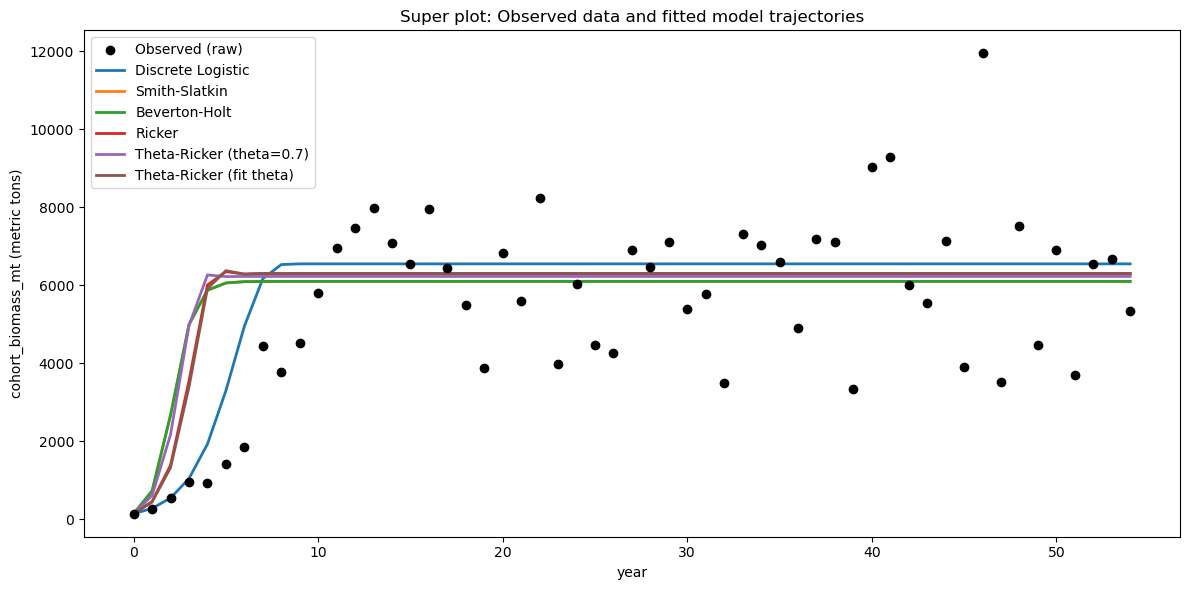

                   Model      RMSE       MAE     AICc      BIC
       Discrete Logistic 1732.2639 1302.1628 824.5211 828.3050
Theta-Ricker (fit theta) 2004.8706 1522.5293 842.8374 848.3888
                  Ricker 2011.3245 1528.0802 840.9511 844.7350
           Beverton-Holt 2039.9037 1578.4743 842.5031 846.2870
           Smith-Slatkin 2039.9047 1578.4751 842.5032 846.2871
Theta-Ricker (theta=0.7) 2062.3441 1574.7682 843.7066 847.4905

Fitted parameter estimates:
Discrete Logistic -> [1.00926720e+00 6.54335439e+03]
Smith-Slatkin -> [1.75611974e+00 6.09328270e+03]
Beverton-Holt -> [5.78989448e+00 7.86094145e-04]
Ricker -> [1.20756459e+00 6.29034880e+03]
Theta-Ricker (theta=0.7) -> [1.58687805e+00 6.22080500e+03]
Theta-Ricker (fit theta) -> [1.17754026e+00 6.29736230e+03 1.03250240e+00]


({'Discrete Logistic': (array([1.00926720e+00, 6.54335439e+03]),
   array([[2.53550760e-02, 2.33831589e+01],
          [2.33831589e+01, 7.96519500e+04]]),
   <function __main__.logistic_map(Nt, r, K)>),
  'Smith-Slatkin': (array([1.75611974e+00, 6.09328270e+03]),
   array([[ 2.12898397e-01, -1.64403877e+01],
          [-1.64403877e+01,  1.06991536e+05]]),
   <function __main__.smith_slatkin_map(Nt, r, K)>),
  'Beverton-Holt': (array([5.78989448e+00, 7.86094145e-04]),
   array([[7.13708481e+00, 1.18360254e-03],
          [1.18360254e-03, 1.98046370e-07]]),
   <function __main__.beverton_holt_map(Nt, lam, alpha)>),
  'Ricker': (array([1.20756459e+00, 6.29034880e+03]),
   array([[2.03370659e-02, 1.56300311e+00],
          [1.56300311e+00, 4.69576966e+04]]),
   <function __main__.ricker_map(Nt, r, K)>),
  'Theta-Ricker (theta=0.7)': (array([1.58687805e+00, 6.22080500e+03]),
   array([[3.42457100e-02, 3.32247741e-01],
          [3.32247741e-01, 5.49529534e+04]]),
   <function __main__.theta

In [18]:
# Fit all five candidate models using scipy.optimize.curve_fit
from scipy.optimize import curve_fit

# Define one-step map functions (return N[t+1] given N[t])
def logistic_map(Nt, r, K):
    return Nt * (1 + r * (1 - Nt / K))

def smith_slatkin_map(Nt, r, K):
    R = np.exp(r)
    return (Nt * R) / (1 + (R - 1) * Nt / K)

def beverton_holt_map(Nt, lam, alpha):
    return (lam * Nt) / (1 + alpha * Nt)

def ricker_map(Nt, r, K):
    return Nt * np.exp(r * (1 - Nt / K))

# Theta-Ricker with theta fixed at 0.7 (assignment spec)
THETA = 0.7
def theta_ricker_map(Nt, r, K):
    return Nt * np.exp(r * (1 - (Nt / K) ** THETA))

# Theta-Ricker with theta as a free parameter
def theta_ricker_free_map(Nt, r, K, theta):
    return Nt * np.exp(r * (1 - (Nt / K) ** theta))

# Helper to fit a one-step map using curve_fit
x = N[:-1]
y = N[1:]

fitted = {}

# Shared initial guesses and bounds
p0_rK = [0.5, max(N) * 1.2]
bounds_rK = ([-5, 1e-6], [5, 1e9])

# 1) Discrete Logistic (r, K)
params, cov = curve_fit(logistic_map, x, y, p0=p0_rK, bounds=bounds_rK, maxfev=20000)
fitted['Discrete Logistic'] = (params, cov, logistic_map)

# 2) Smith-Slatkin (r, K)
params, cov = curve_fit(smith_slatkin_map, x, y, p0=p0_rK, bounds=bounds_rK, maxfev=20000)
fitted['Smith-Slatkin'] = (params, cov, smith_slatkin_map)

# 3) Beverton-Holt (lam, alpha)
p0_bh = [1.1, 1.0 / max(N)]
bounds_bh = ([1e-6, 0.0], [1e3, 1.0])
params, cov = curve_fit(beverton_holt_map, x, y, p0=p0_bh, bounds=bounds_bh, maxfev=20000)
fitted['Beverton-Holt'] = (params, cov, beverton_holt_map)

# 4) Ricker (r, K)
params, cov = curve_fit(ricker_map, x, y, p0=p0_rK, bounds=bounds_rK, maxfev=20000)
fitted['Ricker'] = (params, cov, ricker_map)

# 5a) Theta-Ricker (theta fixed at 0.7): fit r,K
params, cov = curve_fit(theta_ricker_map, x, y, p0=p0_rK, bounds=bounds_rK, maxfev=20000)
fitted[f'Theta-Ricker (theta={THETA})'] = (params, cov, theta_ricker_map)

# 5b) Theta-Ricker fit theta as free param (r, K, theta)
p0_theta = [0.5, max(N) * 1.2, 0.7]
bounds_theta = ([-5, 1e-6, 0.01], [5, 1e9, 5.0])
params, cov = curve_fit(theta_ricker_free_map, x, y, p0=p0_theta, bounds=bounds_theta, maxfev=50000)
fitted['Theta-Ricker (fit theta)'] = (params, cov, theta_ricker_free_map)

# Simulate full trajectories from N[0] using fitted params
simulations = {}
steps = len(N)
for name, (params, cov, func) in fitted.items():
    traj = [float(N[0])]
    # for free-theta func may accept 3 params or 2, so unpack safely
    for t in range(steps - 1):
        try:
            traj.append(func(traj[-1], *params))
        except Exception:
            # fallback: if func expects fewer params (shouldn't happen), use first two
            traj.append(func(traj[-1], params[0], params[1]))
    simulations[name] = np.asarray(traj, dtype=float)

# Super plot: raw data scatter + all fitted trajectories
plt.figure(figsize=(12, 6))
plt.scatter(data.index, N, color='black', label='Observed (raw)', zorder=5)

colors = plt.cm.tab10.colors
for i, (name, traj) in enumerate(simulations.items()):
    plt.plot(data.index, traj, label=f"{name}", color=colors[i % len(colors)], linewidth=2)

plt.xlabel('year')
plt.ylabel('cohort_biomass_mt (metric tons)')
plt.title('Super plot: Observed data and fitted model trajectories')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Compute and print fit metrics (RMSE, MAE, AICc, BIC)
rows = []
n = len(N)
for name, traj in simulations.items():
    residual = np.asarray(N, dtype=float) - traj
    rss = float(np.sum(residual ** 2))
    rss = max(rss, 1e-12)
    rmse = np.sqrt(np.mean(residual ** 2))
    mae = np.mean(np.abs(residual))
    # parameter count
    if name == 'Beverton-Holt':
        k = 2
    elif name == 'Theta-Ricker (fit theta)':
        k = 3
    else:
        k = 2
    aic = n * np.log(rss / n) + 2 * k
    aicc = aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf
    bic = n * np.log(rss / n) + k * np.log(n)

    rows.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'AICc': aicc, 'BIC': bic})

metrics = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
print(metrics.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print('\nFitted parameter estimates:')
for name, (params, cov, func) in fitted.items():
    print(name, '->', params)

# Return/keep objects for later use
fitted_models = fitted
simulations = simulations
metrics = metrics
fitted_models, simulations, metrics

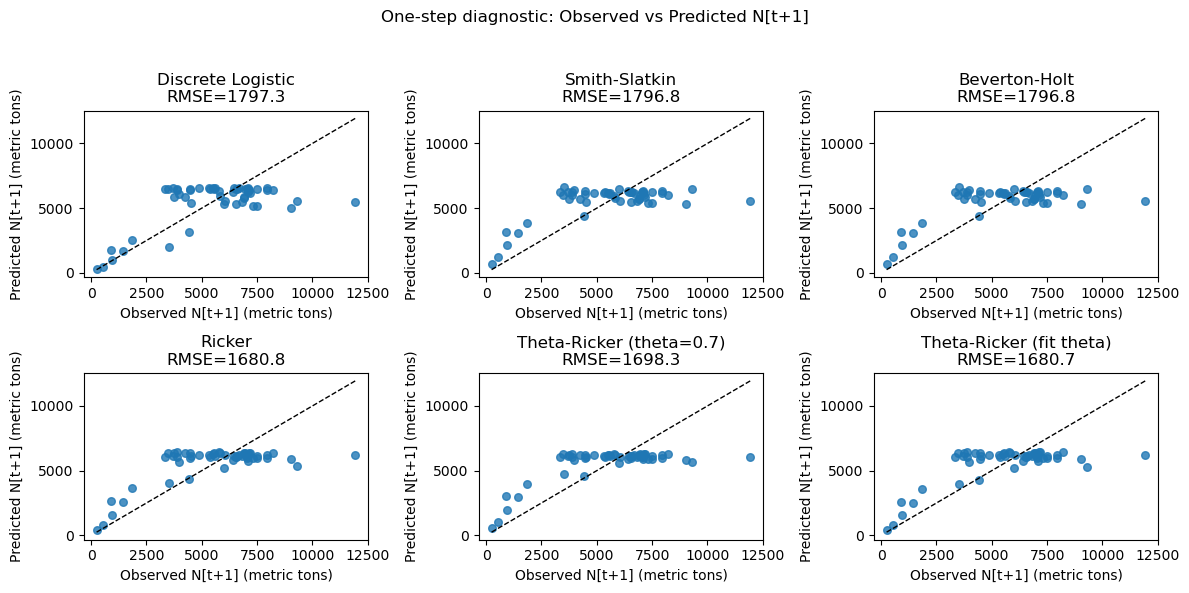

In [19]:
# One-step diagnostic plots: Observed vs Predicted N[t+1] for each model
x = N[:-1]
y_obs = N[1:]

models_for_diag = fitted_models
n_models = len(models_for_diag)

plt.figure(figsize=(12, 6))
cols = 3
rows = int(np.ceil(n_models / cols))

for i, (name, (params, cov, func)) in enumerate(models_for_diag.items()):
    try:
        y_pred = func(x, *params)
    except Exception:
        # fallback unpack
        if len(params) == 3:
            y_pred = func(x, params[0], params[1], params[2])
        else:
            y_pred = func(x, params[0], params[1])

    rmse = np.sqrt(np.mean((y_obs - y_pred) ** 2))

    ax = plt.subplot(rows, cols, i + 1)
    ax.scatter(y_obs, y_pred, s=30, alpha=0.8)
    mn = min(y_obs.min(), y_pred.min())
    mx = max(y_obs.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
    ax.set_xlabel('Observed N[t+1] (metric tons)')
    ax.set_ylabel('Predicted N[t+1] (metric tons)')
    ax.set_title(f"{name}\nRMSE={rmse:.1f}")

plt.suptitle('One-step diagnostic: Observed vs Predicted N[t+1]')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()